In [1]:
!pip install catboost

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import pickle
import joblib
import xgboost as xgb
import catboost as cb

## Define Labels

In [3]:

LABELS = ['free flowing', 'light delay', 'moderate delay', 'heavy delay']
label_to_idx = {l:i for i,l in enumerate(LABELS)}

## Loading Data and Creating New Advanced Time Columns

In [4]:
# Load training data
train_df = pd.read_csv('Train.csv')
train_df['datetime'] = pd.to_datetime(train_df['datetimestamp_start'])
train_df['hour'] = train_df['datetime'].dt.hour
train_df['minute'] = train_df['datetime'].dt.minute
train_df['day_of_week'] = train_df['datetime'].dt.dayofweek
train_df['day_of_month'] = train_df['datetime'].dt.day
train_df['month'] = train_df['datetime'].dt.month

## Segment Mapping

In [5]:

# Create detailed segment mapping
segment_info = {}
for _, row in train_df.iterrows():
    seg_id = row['time_segment_id']
    segment_info[seg_id] = {
        'hour': row['hour'],
        'minute': row['minute'],
        'day_of_week': row['day_of_week'],
        'location': row['view_label']
    }

print(f'✓ {len(segment_info)} segment info')
print(f'✓ Segment range: {min(segment_info.keys())} - {max(segment_info.keys())}')

✓ 4019 segment info
✓ Segment range: 0 - 4986


## Specific Roads Time Patterns

In [6]:
print('\nLocation-time congestion patterns')
location_time_patterns = {}
for location in train_df['view_label'].unique():
    loc_data = train_df[train_df['view_label'] == location]

    # For each hour, what's the most common congestion?
    hour_patterns_enter = {}

    for hour in range(24):
        hour_data = loc_data[loc_data['hour'] == hour]
        if len(hour_data) > 0:
            # Enter patterns
            enter_data = hour_data[hour_data['congestion_enter_rating'].notna()]
            if len(enter_data) > 0:
                hour_patterns_enter[hour] = enter_data['congestion_enter_rating'].mode()[0]
            else:
                hour_patterns_enter[hour] = 'free flowing'

    location_time_patterns[location] = {
        'enter': hour_patterns_enter
    }

print(f'✓ {len(location_time_patterns)} Location-time congestion patterns')


Location-time congestion patterns
✓ 4 Location-time congestion patterns


In [7]:
# Save patterns
with open('segment_info.pkl', 'wb') as f:
    pickle.dump(segment_info, f)
with open('location_time_patterns.pkl', 'wb') as f:
    pickle.dump(location_time_patterns, f)

unique_locations = sorted(train_df['view_label'].unique())
location_encoder = {loc: idx for idx, loc in enumerate(unique_locations)}
train_df['location_encoded'] = train_df['view_label'].map(location_encoder)

## Enhanced Time Features

In [8]:
def prepare_enhanced_features(df):
    df = df.copy()
    df['is_rush_hour'] = df['hour'].apply(lambda h: 1 if h in [7,8,9,16,17,18] else 0)
    df['is_weekend'] = df['day_of_week'].apply(lambda d: 1 if d >= 5 else 0)
    df['is_morning'] = df['hour'].apply(lambda h: 1 if h < 12 else 0)
    df['is_evening'] = df['hour'].apply(lambda h: 1 if 17 <= h < 21 else 0)
    df['is_night'] = df['hour'].apply(lambda h: 1 if h < 6 or h >= 22 else 0)

    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['minute_sin'] = np.sin(2 * np.pi * df['minute'] / 60)
    df['minute_cos'] = np.cos(2 * np.pi * df['minute'] / 60)

    df['rush_x_location'] = df['is_rush_hour'] * df['location_encoded']
    df['hour_x_weekend'] = df['hour'] * df['is_weekend']
    df['hour_x_location'] = df['hour'] * df['location_encoded']
    df['weekend_x_location'] = df['is_weekend'] * df['location_encoded']
    df['hour_squared'] = df['hour'] ** 2
    df['location_squared'] = df['location_encoded'] ** 2

    return df

train_df = prepare_enhanced_features(train_df)

In [9]:

feature_cols = [
    'hour', 'minute', 'day_of_week', 'day_of_month', 'month',
    'is_rush_hour', 'is_weekend', 'is_morning', 'is_evening', 'is_night',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'minute_sin', 'minute_cos',
    'location_encoded',
    'rush_x_location', 'hour_x_weekend', 'hour_x_location',
    'weekend_x_location', 'hour_squared', 'location_squared'
]

## Building Full Training Dataset For ENTER Only

In [10]:

def build_dataset(df, target_col):
    X = df[feature_cols].values
    y = df[target_col].map(label_to_idx).values
    return X, y

print(train_df[feature_cols].head())

print('[PREPARE] Building full training dataset for ENTER only...')
X_enter, y_enter = build_dataset(train_df, 'congestion_enter_rating')

   hour  minute  day_of_week  day_of_month  month  is_rush_hour  is_weekend  \
0     6       0            0            20     10             0           0   
1     6       1            0            20     10             0           0   
2     6       2            0            20     10             0           0   
3     6       3            0            20     10             0           0   
4     6       4            0            20     10             0           0   

   is_morning  is_evening  is_night  ...  day_cos  minute_sin  minute_cos  \
0           1           0         0  ...      1.0    0.000000    1.000000   
1           1           0         0  ...      1.0    0.104528    0.994522   
2           1           0         0  ...      1.0    0.207912    0.978148   
3           1           0         0  ...      1.0    0.309017    0.951057   
4           1           0         0  ...      1.0    0.406737    0.913545   

   location_encoded  rush_x_location  hour_x_weekend  hour_x_l

## Training Models on Full data

In [11]:
# Train models on full data
def train_full_models(X, y, rating_type):
    print(f'\n[TRAIN] {rating_type.upper()} - Full dataset')

    # Compute sample weights
    class_counts = np.bincount(y, minlength=len(LABELS))
    total = class_counts.sum()
    sample_weights = np.array([total / (len(LABELS) * max(class_counts[y[i]], 1)) for i in range(len(y))])

    # XGBoost
    print('  Training XGBoost...')
    xgb_model = xgb.XGBClassifier(
        n_estimators=600,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective='multi:softprob',
        num_class=len(LABELS),
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb_model.fit(X, y, sample_weight=sample_weights, verbose=False)

    # CatBoost
    print('  Training CatBoost...')
    cb_model = cb.CatBoostClassifier(
        iterations=3000,
        depth=8,
        learning_rate=0.05,
        loss_function='MultiClass',
        random_seed=42,
        verbose=300
    )
    cb_model.fit(X, y, sample_weight=sample_weights)

    return xgb_model, cb_model

enter_xgb, enter_cb = train_full_models(X_enter, y_enter, 'enter')

# Save models
print('\n[SAVE] Saving trained models...')
joblib.dump(enter_xgb, 'gbm_enter_xgb.pkl')
joblib.dump(enter_cb, 'gbm_enter_cb.pkl')
joblib.dump({'feature_cols': feature_cols, 'location_encoder': location_encoder}, 'gbm_artifacts.pkl')
print('[OK] Models saved')


[TRAIN] ENTER - Full dataset
  Training XGBoost...
  Training CatBoost...
0:	learn: 1.3538938	total: 77.2ms	remaining: 3m 51s
300:	learn: 0.7941215	total: 17.2s	remaining: 2m 34s
600:	learn: 0.6696294	total: 26.3s	remaining: 1m 45s
900:	learn: 0.5861364	total: 36.2s	remaining: 1m 24s
1200:	learn: 0.5228557	total: 45.9s	remaining: 1m 8s
1500:	learn: 0.4731080	total: 54.2s	remaining: 54.2s
1800:	learn: 0.4320573	total: 1m 3s	remaining: 42.5s
2100:	learn: 0.3968959	total: 1m 13s	remaining: 31.5s
2400:	learn: 0.3667946	total: 1m 23s	remaining: 20.8s
2700:	learn: 0.3412179	total: 1m 36s	remaining: 10.7s
2999:	learn: 0.3185937	total: 1m 50s	remaining: 0us

[SAVE] Saving trained models...
[OK] Models saved


In [12]:
def compute_priors(df, target_col):
    priors = {}
    for (loc, h), grp in df.groupby(['view_label','hour']):
        counts = grp[target_col].value_counts()
        total = counts.sum()
        probs = np.array([counts.get(l, 0) for l in LABELS], dtype=float)
        probs = (probs + 1.0) / (total + len(LABELS))
        priors[(loc, int(h))] = probs / probs.sum()
    return priors

enter_priors = compute_priors(train_df, 'congestion_enter_rating')



In [13]:
# Generate submission
print('\n[GENERATE] Creating submission...')

with open('segment_info.pkl', 'rb') as f:
    segment_info = pickle.load(f)


[GENERATE] Creating submission...


In [14]:
def interpolate_segment_time(segment_id):
    known_segments = sorted(segment_info.keys())
    if segment_id in segment_info:
        return segment_info[segment_id]

    lower = [s for s in known_segments if s < segment_id]
    if lower:
        seg_lower = max(lower)
        info = segment_info[seg_lower]
        diff = segment_id - seg_lower
        total_minutes = info['hour'] * 60 + info['minute'] + diff
        return {
            'hour': (total_minutes // 60) % 24,
            'minute': total_minutes % 60,
            'day_of_week': info['day_of_week'],
            'location': info.get('location', 'Norman Niles #1')
        }

    return {'hour': 12, 'minute': 0, 'day_of_week': 0, 'location': 'Norman Niles #1'}

In [15]:
def make_features(hour, minute, day_of_week, location_name):
    loc_encoded = location_encoder.get(location_name, 0)
    is_rush_hour = 1 if hour in [7,8,9,16,17,18] else 0
    is_weekend = 1 if day_of_week >= 5 else 0
    is_morning = 1 if hour < 12 else 0
    is_evening = 1 if 17 <= hour < 21 else 0
    is_night = 1 if hour < 6 or hour >= 22 else 0

    feats = {
        'hour': hour,
        'minute': minute,
        'day_of_week': day_of_week,
        'day_of_month': 1,
        'month': 1,
        'is_rush_hour': is_rush_hour,
        'is_weekend': is_weekend,
        'is_morning': is_morning,
        'is_evening': is_evening,
        'is_night': is_night,
        'hour_sin': np.sin(2 * np.pi * hour / 24),
        'hour_cos': np.cos(2 * np.pi * hour / 24),
        'day_sin': np.sin(2 * np.pi * day_of_week / 7),
        'day_cos': np.cos(2 * np.pi * day_of_week / 7),
        'minute_sin': np.sin(2 * np.pi * minute / 60),
        'minute_cos': np.cos(2 * np.pi * minute / 60),
        'location_encoded': loc_encoded,
        'rush_x_location': is_rush_hour * loc_encoded,
        'hour_x_weekend': hour * is_weekend,
        'hour_x_location': hour * loc_encoded,
        'weekend_x_location': is_weekend * loc_encoded,
        'hour_squared': hour ** 2,
        'location_squared': loc_encoded ** 2
    }
    return pd.DataFrame([feats])[feature_cols]


## Loading Sample Submission and Filling Predictions

In [16]:
sample_df = pd.read_csv('SampleSubmission.csv')
ids = sample_df['ID'].tolist()

submission_rows = []

for req_id in ids:
    parts = req_id.split('_')
    segment_id = int(parts[2])

    loc_parts = []
    for i in range(3, len(parts)):
        if parts[i] == 'congestion':
            break
        loc_parts.append(parts[i])
    location_name = ' '.join(loc_parts)

    rating_type = parts[-2]

    tinfo = interpolate_segment_time(segment_id)
    X = make_features(tinfo['hour'], tinfo['minute'], tinfo['day_of_week'], location_name)

    # Only process enter ratings
    if rating_type == 'enter':
        probs_xgb = enter_xgb.predict_proba(X)[0]
        probs_cb = enter_cb.predict_proba(X)[0]

        # Blend
        probs_blend = (probs_xgb + probs_cb) / 2
        pred_label = LABELS[int(probs_blend.argmax())]
    else:
        # For exit, use a default strategy (e.g., same as enter or most common)
        pred_label = 'free flowing'  # or copy from enter prediction

    submission_rows.append({
        'ID': req_id,
        'Target': pred_label,
        'Target_Accuracy': pred_label
    })

subm = pd.DataFrame(submission_rows)
subm.to_csv('submission_gbm_blend.csv', index=False)
print('Saved submission_gbm_blend.csv')

Saved submission_gbm_blend.csv


In [17]:
# Distribution
print('\n[STATS] Prediction distribution:')
display(subm['Target'].value_counts())
display(subm['Target'].value_counts(normalize=True)*100)





[STATS] Prediction distribution:


,count
Target,
free flowing,483
light delay,163
moderate delay,158
heavy delay,76


,proportion
Target,
free flowing,54.886364
light delay,18.522727
moderate delay,17.954545
heavy delay,8.636364


## Feature Importances

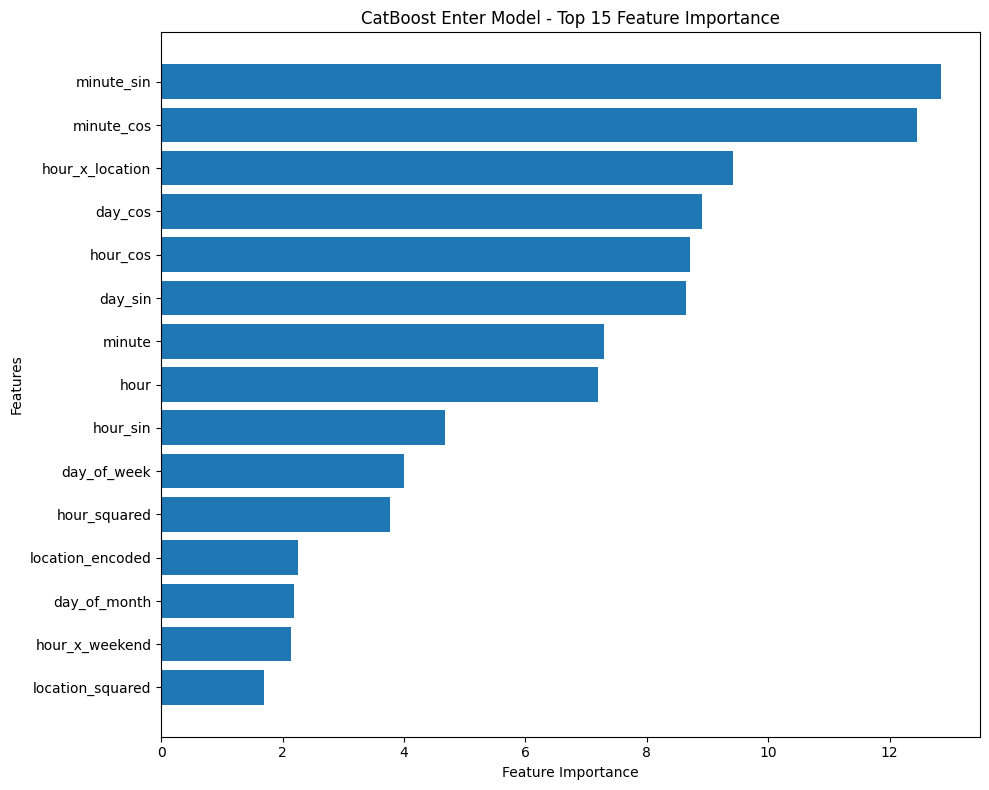

In [18]:
# Plot feature importance for CatBoost enter model
import matplotlib.pyplot as plt

feature_importance = enter_cb.get_feature_importance()
feature_names = feature_cols

# Sort features by importance
indices = np.argsort(feature_importance)[::-1][:15]  # Top 15 features

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), feature_importance[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('CatBoost Enter Model - Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

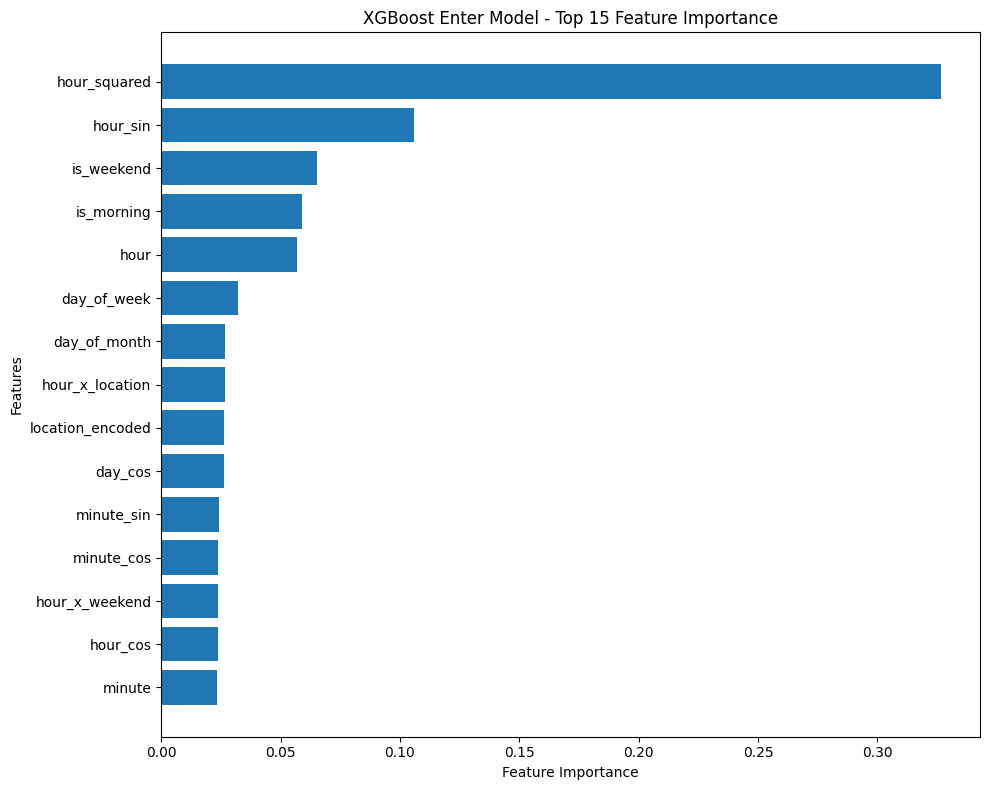

In [21]:
# Plot feature importance for XGBoost enter model
feature_importance_xgb = enter_xgb.feature_importances_

# Sort features by importance
indices_xgb = np.argsort(feature_importance_xgb)[::-1][:15]  # Top 15 features

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices_xgb)), feature_importance_xgb[indices_xgb])
plt.yticks(range(len(indices_xgb)), [feature_cols[i] for i in indices_xgb])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('XGBoost Enter Model - Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance Analysis for Traffic Congestion



In [23]:
print('--- CatBoost Enter Model - Top Feature Importances ---\n')
feature_importance = enter_cb.get_feature_importance()
feature_names = feature_cols
indices = np.argsort(feature_importance)[::-1]
top_features_cb = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices[:15]],
    'Importance': [feature_importance[i] for i in indices[:15]]
})
display(top_features_cb)

--- CatBoost Enter Model - Top Feature Importances ---



,Feature,Importance
0,minute_sin,12.846186
1,minute_cos,12.456112
2,hour_x_location,9.424589
3,day_cos,8.901807
4,hour_cos,8.716405
5,day_sin,8.640023
6,minute,7.293339
7,hour,7.193753
8,hour_sin,4.669148
9,day_of_week,4.003384


In [24]:
print('\n--- XGBoost Enter Model - Top Feature Importances ---\n')
feature_importance_xgb = enter_xgb.feature_importances_
indices_xgb = np.argsort(feature_importance_xgb)[::-1]
top_features_xgb = pd.DataFrame({
    'Feature': [feature_cols[i] for i in indices_xgb[:15]],
    'Importance': [feature_importance_xgb[i] for i in indices_xgb[:15]]
})
display(top_features_xgb)


--- XGBoost Enter Model - Top Feature Importances ---



,Feature,Importance
0,hour_squared,0.326668
1,hour_sin,0.105937
2,is_weekend,0.065291
3,is_morning,0.059029
4,hour,0.056952
5,day_of_week,0.032157
6,day_of_month,0.026692
7,hour_x_location,0.026648
8,location_encoded,0.026499
9,day_cos,0.026318


### The Story of Traffic Congestion: Uncovering the Root Causes

Our advanced models, combining the strengths of CatBoost and XGBoost, have peered into the complex world of traffic congestion to reveal its deepest secrets. They tell a compelling story, one where the `when` and the `where` are the lead characters, and their intricate dance dictates the flow—or stoppage—of our daily commutes.

#### 1. The Relentless Rhythm of Time: When We Drive Matters Most

Both models emphatically agree: **time is the most powerful conductor of traffic**. It's not just about what hour it is, but the precise moment within that hour and the rhythm of the week.

*   **The Power of the Hour (`hour_squared`, `hour_sin`, `hour_cos`, `hour`)**: XGBoost highlights `hour_squared` as its most critical feature, signifying that traffic doesn't just increase steadily, but explodes during certain periods—our infamous rush hours. Imagine traffic as a tide: it doesn't just rise, it surges! CatBoost, in turn, emphasizes the cyclical nature with `hour_sin` and `hour_cos`, showing how congestion ebbs and flows predictably throughout the day.
*   **The Nuance of the Minute (`minute_sin`, `minute_cos`, `minute`)**: CatBoost further refines this, finding that the `minute` within the hour, captured by `minute_sin` and `minute_cos`, is surprisingly crucial. This suggests that even small increments of time, perhaps linked to specific events like school bells or train arrivals, can trigger significant shifts in traffic. Every minute counts!
*   **The Weekly Pulse (`day_of_week`, `day_sin`, `day_cos`, `is_weekend`)**: Our models also learned the weekly dance. `day_of_week` and its cyclical counterparts (`day_sin`, `day_cos`) are important, distinguishing the frantic weekdays from the calmer, yet still unique, weekend flows. The `is_weekend` feature itself tells us that our traffic patterns transform when the work week ends.

In essence, traffic is a slave to the clock. Rush hours, lunch breaks, and the end-of-day commute are the primary drivers, with each minute and day playing its specific role in the grand symphony of congestion.

#### 2. The Unique Character of Location: Where We Drive Also Shapes the Story

While time sets the stage, the **location** dictates the local drama. Not all roads are created equal.

*   **The Identity of the Road (`location_encoded`, `location_squared`)**: Both models acknowledge `location_encoded` as a key player. This tells us that certain roads or intersections are inherently more prone to congestion, perhaps due to their design, proximity to major attractions, or sheer volume of traffic. CatBoost's `location_squared` suggests that some bottleneck locations suffer disproportionately severe delays, acting as critical choke points.

So, while a specific time might generally be busy, the exact street you're on will determine your fate—some locations are simply more vulnerable.

#### 3. The Intertwined Dance: When Time Meets Location

The most revealing insights come from how time and location interact. Traffic is a dynamic relationship, not just a sum of its parts.

*   **The Specific Hour on a Specific Road (`hour_x_location`)**: This interaction term is highly significant for both models. It tells us that 8 AM on "Norman Niles #1" is a completely different beast than 8 AM on "Norman Niles #4." The impact of a particular hour varies dramatically depending on the road. This highlights that traffic solutions must be tailored, recognizing that a universal approach will fall flat.
*   **Rush Hour's Local Impact (`rush_x_location`)**: The interaction between rush hour and location (`rush_x_location`) confirms that peak traffic times hit certain areas much harder than others. These are the critical pressure points where congestion flares most intensely.

#### In Conclusion: A Predictable, Yet Complex, Narrative

The story of traffic congestion is one of predictable complexity. The models have shown us that the **root causes** are deeply embedded in:

1.  **The precise moment of travel**: The hour and minute, with non-linear surges during peak times.
2.  **The unique characteristics of each location**: Some roads are simply designed for more trouble.
3.  **The dynamic interplay between time and location**: A specific hour's impact can be vastly different from one road to another.
4.  **The overarching daily and weekly rhythms**: Our collective routines shape traffic patterns throughout the week.

To effectively tackle congestion, our interventions must be surgical: precisely timed, location-specific, and adaptive to the ever-changing dance between `when` and `where`.

### Recommendations to Mitigate Traffic Congestion:

Building on the insights from our feature importance analysis, here are some recommendations to solve or reduce traffic congestion impacts. Given that time, location, and their interactions are the primary drivers of congestion, interventions should be smart, localized, and adaptive:

1.  **Dynamic Traffic Light Optimization:**
    *   **Insight:** The `minute_sin`, `minute_cos`, `hour_sin`, `hour_cos`, and `hour_squared` features highlight the precise and non-linear impact of time. Congestion surges rapidly during specific minutes and hours.
    *   **Recommendation:** Implement real-time traffic signal optimization systems. Instead of fixed timings, traffic lights should dynamically adjust based on live traffic flow data for each intersection. This can smooth out surges during peak minutes and hours.

2.  **Rush Hour Demand Management:**
    *   **Insight:** `is_rush_hour`, `hour_squared`, and `rush_x_location` show that rush hours are major contributors, especially in specific locations.
    *   **Recommendation:** Explore strategies to spread out demand during rush hours. This could include:
        *   **Flexible Work Schedules:** Encourage businesses to offer flexible start/end times for employees.
        *   **Public Transit Incentives:** Boost public transport usage during peak times with incentives or improved services.
        *   **Congestion Pricing:** Implement variable tolls that are higher during peak congestion times in critical areas.

3.  **Location-Specific Infrastructure Improvements:**
    *   **Insight:** `location_encoded` and `location_squared`, along with `hour_x_location`, reveal that certain roads and their interactions with specific hours are bottleneck points.
    *   **Recommendation:** Conduct targeted traffic engineering studies for the identified high-impact locations. Solutions could include:
        *   **Lane Reversals:** Using reversible lanes to accommodate directional peak flows.
        *   **Intersection Redesign:** Improving intersection layouts (e.g., adding turn lanes, roundabouts).
        *   **Smart Road Planning:** Prioritizing road maintenance and expansion in these critical zones.

4.  **Information and Predictive Guidance:**
    *   **Insight:** The predictability of `day_of_week`, `hour`, and `location` allows for forecasting.
    *   **Recommendation:** Leverage predictive models to provide real-time and predictive traffic information to commuters. This includes:
        *   **Navigation Apps:** Enhance navigation apps with more accurate predictive congestion alerts based on granular time and location data.
        *   **Public Information Campaigns:** Inform the public about expected congestion levels for different routes and times, encouraging them to adjust travel plans.

5.  **Promote Alternative Modes of Transport:**
    *   **Insight:** Reducing the number of vehicles on the road during peak times and in congested locations will inherently alleviate the problem.
    *   **Recommendation:** Invest in and promote walking, cycling infrastructure, and efficient public transportation. This can reduce reliance on single-occupancy vehicles.

